## シュミレーションをやってみよう

　勉強会の資料では先決変数と非先決変数がちょうど1つずつあったが、今回のコードでは複数の変数にも対応できる形にしているため、変数の多くがベクトル，行列表記になっている。

### 0. 必要なパッケージをインストールする

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import japanize_matplotlib

### 1. モデルを再現する
　Ramseyモデルは以下の2本の式によって成立していた。
\begin{equation}
\left\{
\begin{alignedat}{2}
\ \ \frac{c_{t+1}}{c_{t}} & = \beta\left\{\alpha k_{t+1}^{\alpha-1}-\delta+1 \right\} \\
\ \ k_{t+1} & = k_{t}^{\alpha}+(1-\delta)k_{t}-c_{t}
\end{alignedat}
\right.
\end{equation}
#### 変数
$c_{t}$：1人当たり消費,
$k_{t}$：1人当たり資本ストック
#### パラメータ
$\alpha$：資本分配率,
$\beta$：時間割引率,
$\delta$：資本減耗率

In [2]:
# 変数およびパラメータを定義する
c0, c1, k0, k1 = sp.symbols("c0, c1, k0, k1")
α, β, δ = sp.symbols("α, β, δ")

# パラメータの値を定義する
params = {α: 0.3,
          β: 0.99,
          δ: 0.25
         }

# モデルの関数を定義する
f1 = c1/c0-β*(α*k1**(α-1)-δ+1)
f2 = k1-k0**α-(1-δ)*k0+c0

モデルの関数は=0になるように変形し、のちのニュートン法が計算しやすくしている。

### 2. 関数を行列に変換する
　pythonでシュミレーションする場合、numpyを使うのが便利なのでf1,f2をまとめて行列にしておく。

In [3]:
# 関数の行列を作る
F = sp.Matrix([f1, f2]).subs({     #ついでに定常状態を仮定した
    c1: c0, k1: k0
})
F_param = F.subs(params) # パラメータに実数を代入する

### 3. 定常状態を計算する
　ここでは多変数の場合のニュートン法を用いて数値計算する。はじめに必ず必要になるヤコビ行列を作成するコードを作っておく。
ヤコビ行列とは多変数ベクトル関数$\boldsymbol{f}(\boldsymbol{x})$を各成分の軸方向に対する微分係数を行列表記したものであり、具体的には、
\begin{align}
\boldsymbol{f}(\boldsymbol{x})=
\begin{bmatrix}
f_{1}(x_{1}, x_{2}, \cdots, x_{n}) \\
f_{2}(x_{1}, x_{2}, \cdots, x_{n}) \\
\vdots \\
f_{m}(x_{1}, x_{2}, \cdots, x_{n})
\end{bmatrix}
\end{align}
であるとき$\boldsymbol{f}$のヤコビ行列は、
\begin{align}
J=
\begin{bmatrix}
\frac{\partial f_{1}}{\partial x_{1}} & \frac{\partial f_{1}}{\partial x_{2}} & \cdots & \frac{\partial f_{1}}{\partial x_{n}} \\
\frac{\partial f_{2}}{\partial x_{1}} & \frac{\partial f_{2}}{\partial x_{2}} & \cdots & \frac{\partial f_{2}}{\partial x_{n}} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_{m}}{\partial x_{1}} & \frac{\partial f_{m}}{\partial x_{2}} & \cdots & \frac{\partial f_{m}}{\partial x_{n}} \\
\end{bmatrix}
\end{align}
である。

In [4]:
# jacobian行列を作成する関数
def Jacobian(F, N, X): # F: 元の関数, N: 変数の数, X: 変数のリスト
    J = []
    for j in range(N):
        a = [F[j].diff(i) for i in X] # 第j行の関数を各変数で微分し、リストに並べる
        J.append(a)
    
    J = sp.Matrix(J) # 返す結果をsympyの形にしておく
    
    return J

Ramseyモデルの場合変数は2個なので変数のリストと合わせてヤコビ行列は

In [5]:
n_x = 1
n_s = 1
N = n_x + n_s
X = [c0, k0]
J_param = Jacobian(F_param, N, X)

とすると計算できる。ただし,n_xは非先決変数の数,n_sは先決変数の数である。次にヤコビ行列を利用してニュートン法によって定常状態の変数の値を計算する。多変数のニュートン法は、
\begin{align}
\boldsymbol{x}=
\boldsymbol{\bar{x}}-\bar{J} \boldsymbol{\bar{f}} 
\end{align}
ただし$\boldsymbol{\bar{x}}$は任意の実数の変数ベクトルであり$\boldsymbol{\bar{x}}=(\bar{x}_1, \bar{x}_{2}, \cdots, \bar{x}_{n})$である。同様に$\bar{j}$と$\boldsymbol{\bar{f}}$も任意の実数ベクトルの下でのヤコビ行列および関数ベクトルである。新たに計算された左辺の変数ベクトルを新たな$\boldsymbol{\bar{x}}$として計算を繰り返すことで解を近似する。

　ニュートン法を用いるにあたって初期値のせえっていおよび繰り返しの終了条件を明記する必要がある。今回は初期値は2変数とも1とし、収束条件は全ての関数の合計値が$10^{-15}$を下回ったとき終了するようにした。また、念のため収束しない場合を考慮して強制終了するような変数も設けた。すなわち、

In [6]:
# 定常状態における変数の値を求める

x_init = np.ones(N) # 初期値
max_loop = 20 # 強制終了の条件
error = 1e-15 # 収束条件

である。いよいよニュートン法のコードを書く。

In [7]:
def newton(F, J, X, x_init, N, error, max_loop):
    # F: 解を求めるための関数
    # J: jacobian行列
    # X: 変数のリスト
    # x_init: 各変数の初期値
    # error: 収束判定の基準
    # max_loop: max_loop
    def variable_num(X, x_init, N): # 変数と初期値の関係を辞書にしておく
        variable_num = {X[i]: x_init[i] for i in range(N)} 
        
        return variable_num
    i = 0
    while np.sum(abs(F_param.subs(variable_num(X, x_init, N)))) >= error:
        
        i += 1
        if i >= max_loop:
            print("Error: Newton nethod did NOT finish normally")
            break
            
        # F_param と J_param　に初期値を代入
        F_init = F.subs(variable_num(X, x_init, N))
        J_init = J.subs(variable_num(X, x_init, N))
        
        # numpyで計算してもらうてもらうために変換
        F_init = np.array(F_init).astype(float)
        J_init = np.array(J_init).astype(float)
        
        # 解く
        x_sol = x_init.reshape(N,1) - np.linalg.solve(J_init, F_init)
        
        x_init = x_sol # 新たな初期値を定義する
            
    return x_sol

実際に計算してもらう。

In [8]:
ss = newton(F_param, J_param, X, x_init, N, error, max_loop)
c_star = ss[0]
k_star = ss[1]

結果を出力すると以下のようになった。

In [9]:
variable = ["c_star" , "k_star"]
for i in range(N):
    print(variable[i]+ "=" + str(ss[i][0]))

c_star=0.7565354289148452
k_star=1.226144733357211


### 4. 対数線形近似を用いた位相図を作成する
　定常解が求まったところでいよいよ位相図を出力するための準備を始める。まずは対数線形近似されたRamsyモデルを定義して関数を行列化する。

In [10]:
f1 = c1-c0-β*α*(α-1)*k_star**(α-1)*k1
f2 = k1-(k_star**α+(1-δ)*k_star)*k0+c_star*c0

F = sp.Matrix([f1,f2])
F_param = F.subs(params)

　次にFの係数行列を作成するがここは若干難しいが落ち着いて考えればできると思われる。

In [11]:
def Coefficient_Matrix(F, X, Y, N):
    # X: 係数が知りたい変数
    # Y: 係数が知りたくない変数
    c = []
    def X_value(X,N,k): # 係数が知りたい変数を1、ほかの変数を0にする
        # X: 係数を知りたい変数
        # i: 数式の指定
        I = range(0,N,1) # 1からNまでの数列
        E = np.eye(N) # 単位行列
        a = {X[i]: j for i, j in zip(I, E[k])}

        return a # 関数に定数項がある場合は注意

    # 係数行列を作成する
    for i in range(N):
        b = [F[i].subs(X_value(X, N, k)).subs({
            Y[i]:0 for i in range(N)
        }) for k in range(N)] # 第i行の係数ベクトルを作成

        c.append(b)
    
    return c

$t+1$期の係数行列をB、$t$期の係数行列をCと定義して実際に計算してもらう。

In [12]:
B = Coefficient_Matrix(F_param, [c1, k1], [c0, k0],N)
C = Coefficient_Matrix(F_param, [c0, k0], [c1, k1],N)

B = np.array(B).astype(float)
C = (-1)* np.array(C).astype(float) # もともと左辺に移行していたので-1を掛けて符号を戻す

下の2行はpython上のテクニックなので重要ではない。

 $A=C^{-1}B$を定義し、$A$の固有値と固有ベクトルを求める。

In [13]:
A = np.linalg.solve(C,B)
A_eig_val, A_eig_vec = np.linalg.eig(A)

A_eig_val = A_eig_val.tolist()
A_eig_vec = A_eig_vec.T.tolist() # 固有値ベクトルを行ベクトルに変換

　計算の都合上、固有値は小さい順になったほうが楽なので並べ替える。

In [14]:
# 固有値と固有値ベクトルの順番を小さい順に書き換える
def eig(Value, Vector, N): # Value: 固有値, Vector: 固有値ベクトル
    
    val = []
    vec = []
    for i in range(N):
        k = np.argmin(Value) # 最小のインデックスを求める
        val.append(Value[k]) # 新たに作ったリストに最小値を挿入する
        vec.append(Vector[k])
        del Value[k] # 次の最小値を探す作業のために消去
        del Vector[k]
        
        
    return val, vec


A_eig_val, A_eig_vec = eig(A_eig_val, A_eig_vec, N) # 小さい順にしたlistを返す

A_eig_val = np.array(A_eig_val) #numpyに戻しておく
A_eig_vec = np.array(A_eig_vec).T

 ここまでくるとあとはとAを地道に計算すればよいので一気にいこう。

In [15]:
V_s = np.diag(A_eig_val[n_x:]) #V_s: 先決変数に対応する固有値の対角行列（今回はスカラー）

Q = np.linalg.inv(A_eig_vec)

# 行列Qを4分割する
def submatrix(A, line_start, row_start, line_range, row_range):
    # A: 分割する行列
    # line_start: 行の取得するスタート位置
    # row_start: 列の取得するスタート位置
    # line_range: 取得する行数
    # row_range: 取得する列数
    a = []
    for i in range(line_range):
        b = [A[line_start+i][row_start+j] for j in range(row_range)]
        a.append(b)
        
        
    return a

Q_A = submatrix(Q, 0, 0, n_x, n_x) # 分割した行列を取得
Q_B = submatrix(Q, 0, n_x, n_x, n_s)
Q_C = submatrix(Q, n_x, 0, n_s, n_x)
Q_D = submatrix(Q, n_x, n_x, n_s, n_s)

Q_A = np.array(Q_A)
Q_B = np.array(Q_B)
Q_C = np.array(Q_C)
Q_D = np.array(Q_D)

P = - np.linalg.solve(Q_A, Q_B) # Policy function の係数(行列)を求める

PE = np.dot(Q_C, P) + Q_D

A = np.dot(np.linalg.solve(PE, np.linalg.inv(V_s)), PE)

ようやっとPとAが求まったのでシュミレーションをやってみる。さっそくシュミレーションのコードを書いておく。

In [16]:
def simulation(P, A, S_init, X_init, T):
    # T: シュミレーションの期間
    
    X = np.zeros(T*n_x).reshape(n_x, T) # あらかじめ解となるリストを作っておく
    S = np.zeros(T*n_s).reshape(n_s, T)
    
    for i in range(n_x): # X に初期値を代入
        X[i][0] = X_init[i]
        
    for i in range(n_s):
        S[i][0] = S_init[i]
        
    # 逐次代入によって各期の変数の解を求める
    for i in range(T-1):
        x1 = np.dot(np.dot(P, A), S_init) # 来期の Jump variable を求める
        s1 = np.dot(A, S_init) # 来期の Pre-determined variable を求める
        
        for j in range(n_x): # リストに解を代入していく
            X[j][i+1] = x1[j]
        for j in range(n_s):
            S[j][i+1] = s1[j]
            
        S_init = s1 # 新たな初期値を定義する
    
    Y = np.zeros(N*(T+1)).reshape(N, T+1) # X と S　をまとめる
    
    for i in range(N):
        if i < n_x:
            Y[i] = np.r_[0, X[i]] # 初期値の変化率は0
        else:
            Y[i] = np.r_[0, S[i-n_x]]
            
            
            
    return Y

最後に結果をプロットするためのコードを書くが、今回は資本ストックの初期値$k_{0}$が定常状態の約1/2と2倍の地点からスタートさせたい。ただし今回の変数は対数値でみた定常状態からの乖差率となってしまっているため、以下のように考える。
\begin{align}
k_{0}=a k^{*}
\end{align}
上式の対数をとる。
\begin{align}
\ln k_{0} = \ln a +\ln k^{*} \\
\Leftrightarrow k\equiv \ln k_{0}-\ln k^{*} = \ln a
\end{align}
$a$が定常状態と現在の資本ストック水準の関係を表しているため、$a=1/2,2$とすればよい。

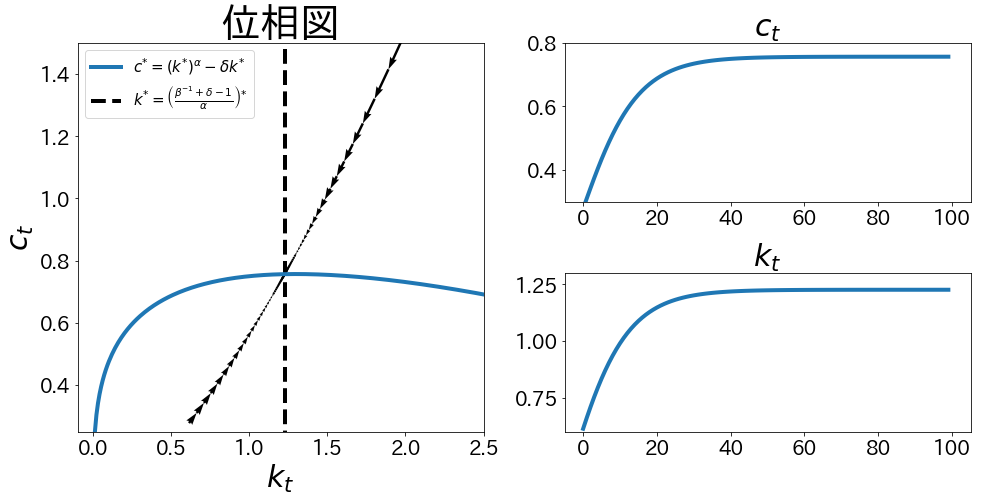

In [17]:
fig = plt.figure()
ax1 = plt.subplot(1,2,1)

init_list = [0.5, 2]
T = 100

for i in init_list:
    S_init = np.array([np.log(i)]) # Pre-determined variavle の初期値を定義
    X_init = np.dot(P, S_init.T) # Jump variavle の初期値
    
    SS = simulation(P, A, S_init, X_init, T)
    
    ln_c_list = SS[0][1:]+np.log(c_star)
    ln_k_list = SS[1][1:]+np.log(k_star)
    
    c_list = np.exp(ln_c_list)
    k_list = np.exp(ln_k_list)

    ax1.quiver(k_list[:-1], c_list[:-1],
              k_list[1:] - k_list[:-1],
              c_list[1:] - c_list[:-1],
              scale_units='xy', angles='xy', scale=1)

    if i==init_list[0]:
        
        ax2 = plt.subplot(2,2,2)
        ax2.plot(c_list, linewidth=4)
        ax2.set_xlim(-5,105)
        ax2.set_ylim(0.3,0.8)
        ax2.set_title(r"$c_{t}$", fontsize=30)
        ax2.tick_params(labelsize=20)
        
        ax3 = plt.subplot(2,2,4)
        ax3.plot(k_list, linewidth=4)
        ax3.set_xlim(-5,105)
        ax3.set_ylim(0.6,1.3)
        ax3.set_title(r"$k_{t}$", fontsize=30)
        ax3.tick_params(labelsize=20)
    else:
        continue
        
k = np.arange(0, 3, 0.01)
alpha, delta, beta = 0.3, 0.25, 0.99 
c_star = k**alpha - delta*k

ax1.plot(k, c_star, linewidth=4,
         label= r"$c^{*}=(k^{*})^{\alpha}-\delta k^{*}$")
ax1.vlines(k_star,0,2, linestyle='--', linewidth=4,
           label=r"$k^{*}=\left(\frac{\beta^{-1}+\delta-1}{\alpha} \right)^{*}$")
legend = ax1.legend(fontsize=15)
ax1.tick_params(labelsize=20)

ax1.set_xlim(-0.1,2.5)
ax1.set_ylim(0.25,1.5)
ax1.set_xlabel(r"$k_{t}$", size=30)
ax1.set_ylabel(r"$c_{t}$", size=30)
ax1.set_title("位相図", size=40)

fig.set_size_inches(16,8)
fig.subplots_adjust(top=0.8,wspace=0.2, hspace=0.45)
plt.show()

次のコードはインパルス反応を出力するためのものである。
インパルス反とは第$t$期の経済変数とその変数の定常値の階差率を対数値で近似したものである。勉強会の資料では、例えば
\begin{align}
\hat{c}_t=\ln c_{t} - \ln c^{*}
\end{align}
などである。RBCモデルやニューケインジアンモデルでは通常インパルス反応を用いて分析をおこなう。

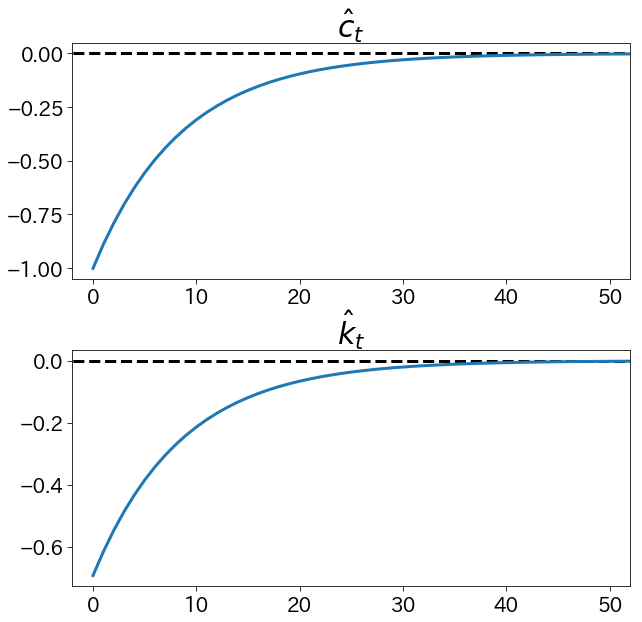

In [18]:
fig, axes = plt.subplots(2, figsize=(10, 10))
plt.subplots_adjust(wspace=0.2, hspace=0.3)



S_init = np.array([np.log(0.5)]) # Pre-determined variavle の初期値を定義
X_init = np.dot(P, S_init.T) # Jump variavle の初期値
    
SS = simulation(P, A, S_init, X_init, T)

title = [r"$\hat{c}_{t}$", r"$\hat{k}_{t}$"]
i = 0
while i <= 1:
    axes[i].plot(SS[i][1:], linewidth=3)
    axes[i].hlines(0, -5, 105, linestyle="--", linewidth=3)
    axes[i].set_xlim(-2, 52)
    axes[i].tick_params(direction="out", length=5, labelsize=15)
    axes[i].set_title(title[i], fontsize=30)
    axes[i].tick_params(direction="out", length=5, labelsize=20)      
    
    i += 1
